In [1]:
import torch
import os
import monai.transforms as mt
import monai.data as md
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


device_id =5
# 设置 PyTorch 的默认 CUDA 设备
torch.cuda.set_device(device_id)

# 确认当前默认 CUDA 设备
current_device = torch.cuda.current_device()
print(f"Switched to CUDA device: {current_device}")

Switched to CUDA device: 5


Image saved to ./radar_chartav5.svg


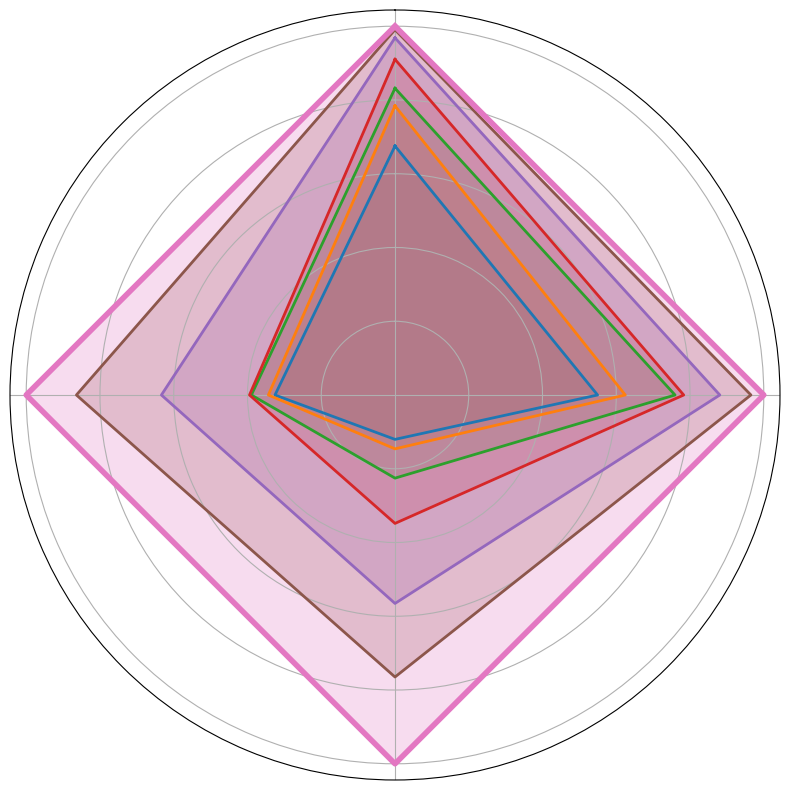

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os
# 数据定义
methods = ['Cyclegan', 'Swin-Unet', 'DDIM(3D)', 'SegGuidedDif', 'Rectified Flow', 'Ours(single)', 'Ours']
metrics = ['SSIM (%) ↑', 'PSNR ↑', 'MSE (%) ↓', 'MAE (%) ↓']  # 标注方向性
data = [
    [59.56, 15.43, 3.24, 8.39],  # Cyclegan
    [69.16, 17.54, 2.67, 7.95],  # Swin-Unet
    [73.37, 21.33, 1.73, 7.01],  # DDIM(3D)
    [80.29, 21.99, 1.12, 6.92],  # SegGuidedDif
    [85.43, 24.74, 0.69, 4.31],  # Rectified Flow
    [87.37, 27.11, 0.51, 3.16],  # Ours(single)
    [88.21, 28.09, 0.39, 2.73]   # Ours
]
# data = [
#     [67.82, 17.26, 2.35, 6.47],
# [75.29,	19.82,	1.27,	5.76],
# [82.62,	23.09,	0.98,	3.98],
# [84.85,	23.76,	0.57,	3.73],
# [85.69,	24.96,	0.53,	3.52],
# [87.48,	26.51,	0.43,	3.08],
# [89.94,	28.72,	0.33,	2.96],
# ]

# 数据标准化处理（对于↑指标越大越好，对于↓指标越小越好）
# 数据标准化处理（对于↑指标越大越好，对于↓指标越小越好）
def normalize_data(data):
    normalized_data = []
    for row in data:
        norm_row = []
        for i, value in enumerate(row):
            if "↑" in metrics[i]:  # 越大越好
                norm_row.append(value / max([r[i] for r in data]))
            elif "↓" in metrics[i]:  # 越小越好
                norm_row.append(min([r[i] for r in data]) / value)
        normalized_data.append(norm_row)
    return normalized_data

normalized_data = normalize_data(data)

# 创建雷达图
def plot_radar_chart(methods, metrics, data, save_path=None):
    num_vars = len(metrics)
    angles = np.linspace(0, 2 * pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # 闭合图形

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 绘制每个方法的线
    colors = plt.cm.tab10.colors  # 使用 tab10 颜色映射
    for i, method in enumerate(methods):
        values = data[i]
        values += values[:1]  # 闭合图形
        linewidth = 2 if method != 'Ours' else 4  # 突出 'Ours'
        ax.plot(angles, values, color=colors[i], label=method, linewidth=linewidth)
        ax.fill(angles, values, color=colors[i], alpha=0.25)

    # 设置标签
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), [m.split(" ")[0] for m in metrics], fontsize=12)
    ax.set_xticklabels([])


    # 增加网格线
    ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0], angle=0, weight='black', fontsize=10)
    ax.set_yticklabels([])


    # 添加图例和标题
    # legend = plt.legend(frameon=False, loc='center', ncol=7)
    # ax.legend(loc='best', fontsize=12)
    # legend = fig.legend(methods, loc='upper center', ncol=7)
    # plt.title("FDG-PET Reconstruction on ADNI", size=16, y=1.1)

    # 调整布局
    plt.tight_layout()

    # 如果提供了保存路径，则保存图像
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 确保目录存在
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight', transparent=True)  # 保存图像，设置高分辨率
        print(f"Image saved to {save_path}")

    plt.show()

# 指定保存路径
save_path = "./radar_chartav45.svg"

# 调用函数绘制蛛网图并保存
plot_radar_chart(methods, metrics, normalized_data, save_path)

Image saved to ./radar_chartfanhua.svg


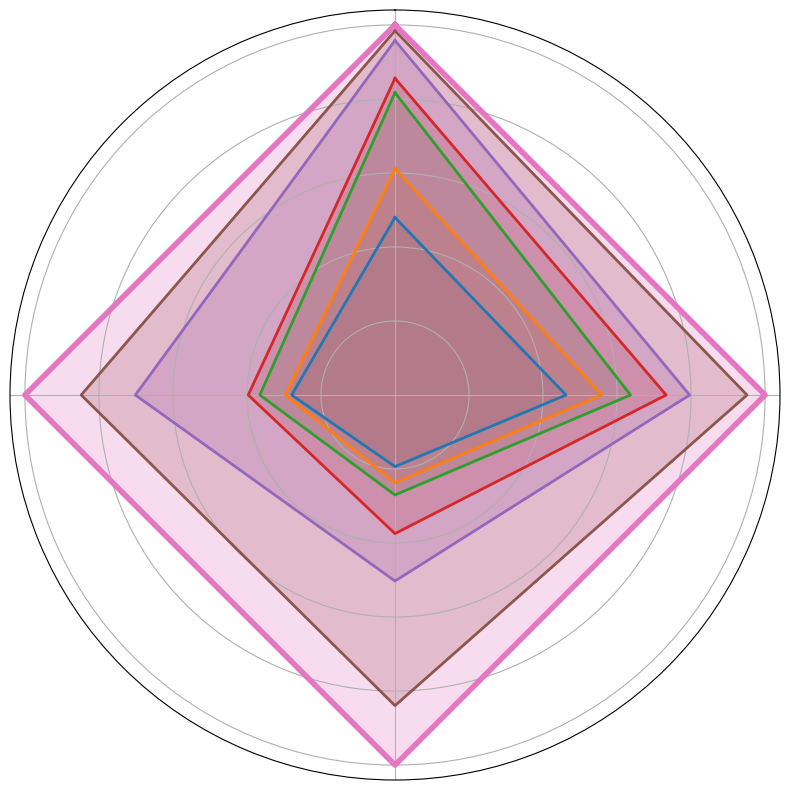

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os

# 数据定义
methods = ['Cyclegan', 'Swin-Unet', 'DDIM(3D)', 'SegGuidedDif', 'Rectified Flow', 'Ours(single)', 'Ours']
metrics = ['SSIM (%) ↑', 'PSNR ↑', 'MSE (%) ↓', 'MAE (%) ↓']  # 标注方向性
data = [
    [40.27, 12.38, 4.86, 10.78],  # Cyclegan
    [51.34, 14.96, 3.96, 10.16],  # Swin-Unet
    [68.59, 17.05, 3.48, 8.24],   # DDIM(3D)
    [71.85, 19.63, 2.51, 7.59],   # SegGuidedDif
    [80.44, 21.33, 1.87, 4.29],   # Rectified Flow
    [82.66, 25.48, 1.12, 3.55],   # Ours(single)
    [83.97, 26.79, 0.94, 3.01]    # Ours
]

# 数据标准化处理（对于↑指标越大越好，对于↓指标越小越好）
def normalize_data(data):
    normalized_data = []
    for row in data:
        norm_row = []
        for i, value in enumerate(row):
            if "↑" in metrics[i]:  # 越大越好
                norm_row.append(value / max([r[i] for r in data]))
            elif "↓" in metrics[i]:  # 越小越好
                norm_row.append(min([r[i] for r in data]) / value)
        normalized_data.append(norm_row)
    return normalized_data

normalized_data = normalize_data(data)

# 创建雷达图
def plot_radar_chart(methods, metrics, data, save_path=None):
    num_vars = len(metrics)
    angles = np.linspace(0, 2 * pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # 闭合图形

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 绘制每个方法的线
    colors = plt.cm.tab10.colors  # 使用 tab10 颜色映射
    for i, method in enumerate(methods):
        values = data[i]
        values += values[:1]  # 闭合图形
        linewidth = 2 if method != 'Ours' else 4  # 突出 'Ours'
        ax.plot(angles, values, color=colors[i], label=method, linewidth=linewidth)
        ax.fill(angles, values, color=colors[i], alpha=0.25)

    # 设置标签
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), [m.split(" ")[0] for m in metrics], fontsize=12)
    ax.set_xticklabels([])


    # 增加网格线
    ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0], angle=0, weight='black', fontsize=10)
    ax.set_yticklabels([])


    # 添加图例和标题
    # ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
    # legend = fig.legend(methods, loc='upper center', ncol=7)

    # plt.title("AV45-PET Reconstruction on ADNI", size=16, y=1.1)

    # 调整布局
    plt.tight_layout()

    # 如果提供了保存路径，则保存图像
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 确保目录存在
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight', transparent=True)  # 保存图像，设置高分辨率
        print(f"Image saved to {save_path}")

    plt.show()

# 指定保存路径
save_path = "./radar_chartfanhua.svg"

# 调用函数绘制蛛网图并保存
plot_radar_chart(methods, metrics, normalized_data, save_path)